In [22]:
import numpy as np
import pandas as pd

np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size = num_data) * 4)
df = pd.DataFrame(data.T, columns = ["data"])

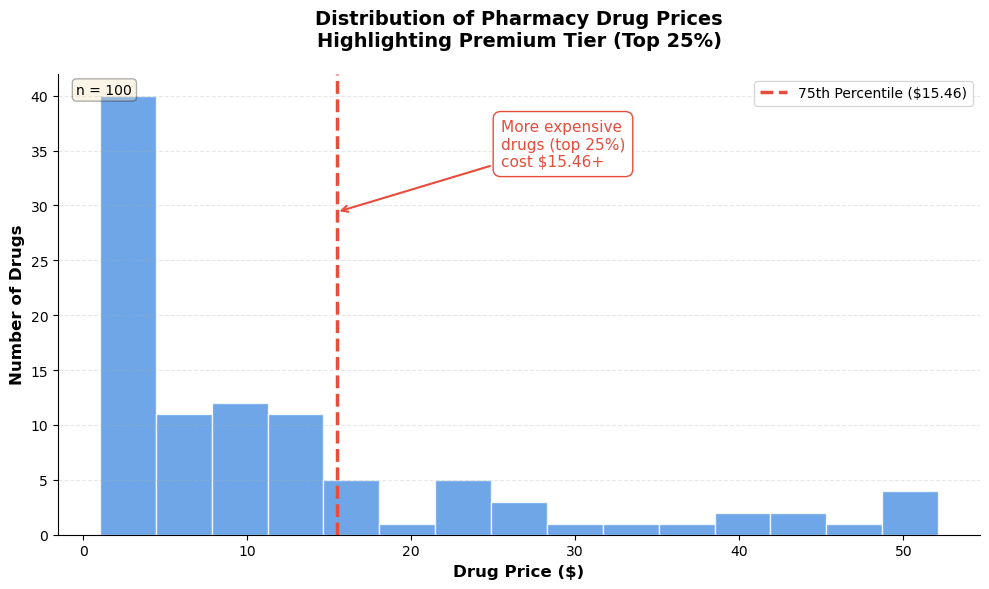

The 75th percentile is: $15.46
This means 25% of drugs cost more than $15.46


In [23]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Your existing data
np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size=num_data) * 4)
df = pd.DataFrame(data.T, columns=["data"])

# Calculate 75th percentile
percentile_75 = df['data'].quantile(0.75)

# Create enhanced histogram
fig, ax = plt.subplots(figsize=(10, 6))

# Plot histogram with better styling
ax.hist(df['data'], bins=15, color='#4A90E2', edgecolor='white', alpha=0.8)

# Add vertical line at 75th percentile
ax.axvline(percentile_75, color='#E74C3C', linestyle='--', linewidth=2.5, 
           label=f'75th Percentile (${percentile_75:.2f})')

# Add annotation for the line
ax.annotate(f'More expensive\ndrugs (top 25%)\ncost ${percentile_75:.2f}+',
            xy=(percentile_75, ax.get_ylim()[1] * 0.7),
            xytext=(percentile_75 + 10, ax.get_ylim()[1] * 0.8),
            fontsize=11,
            color='#E74C3C',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='#E74C3C'),
            arrowprops=dict(arrowstyle='->', color='#E74C3C', lw=1.5))

# Styling
ax.set_xlabel('Drug Price ($)', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Drugs', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Pharmacy Drug Prices\nHighlighting Premium Tier (Top 25%)', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add sample size
ax.text(0.02, 0.98, f'n = {len(df)}', transform=ax.transAxes,
        fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.show()

print(f"The 75th percentile is: ${percentile_75:.2f}")
print(f"This means 25% of drugs cost more than ${percentile_75:.2f}")

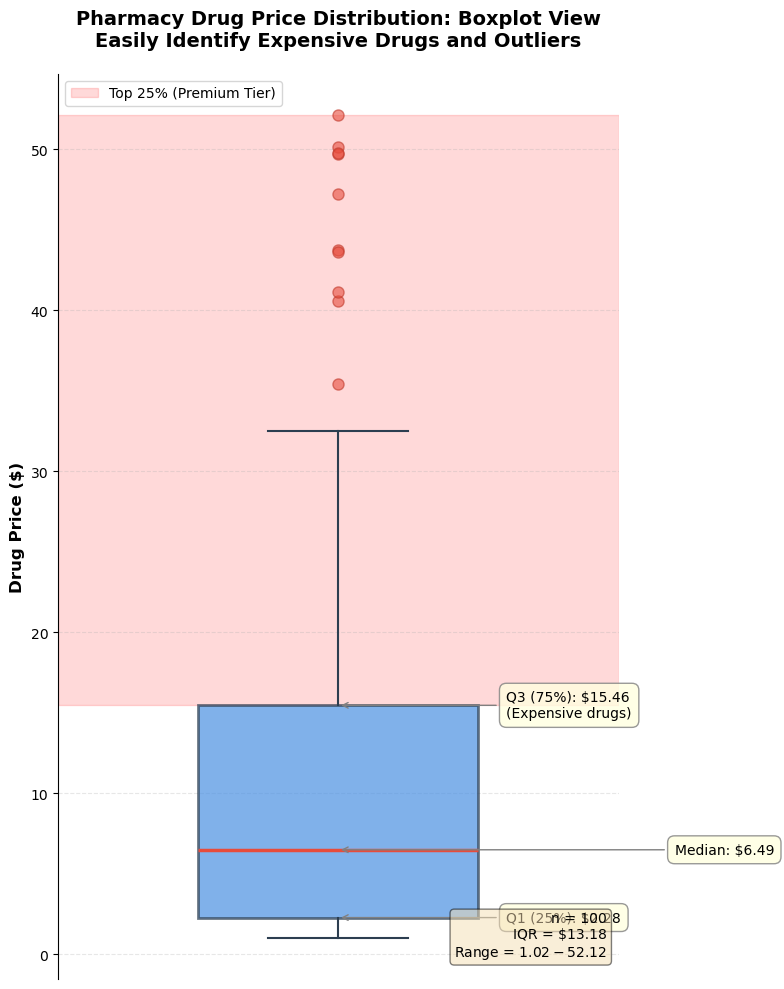


Key Statistics:
Median drug price: $6.49
75th percentile (expensive threshold): $15.46
Top 25% of drugs cost between $15.46 and $52.12


In [24]:
# Create enhanced VERTICAL boxplot
fig, ax = plt.subplots(figsize=(8, 10))

# Create boxplot with custom styling (vert=True or just remove it - vertical is default)
bp = ax.boxplot(df['data'], patch_artist=True,
                widths=0.5,
                boxprops=dict(facecolor='#4A90E2', alpha=0.7, edgecolor='#2C3E50', linewidth=2),
                whiskerprops=dict(color='#2C3E50', linewidth=1.5),
                capprops=dict(color='#2C3E50', linewidth=1.5),
                medianprops=dict(color='#E74C3C', linewidth=2.5),
                flierprops=dict(marker='o', markerfacecolor='#E74C3C', markersize=8, 
                               markeredgecolor='#C0392B', alpha=0.6))

# Calculate statistics
q1 = df['data'].quantile(0.25)
median = df['data'].median()
q3 = df['data'].quantile(0.75)
iqr = q3 - q1
minimum = df['data'].min()
maximum = df['data'].max()

# Add annotations for key statistics (adjusted for vertical orientation)
annotations = [
    (q1, 'Q1 (25%): ${:.2f}'),
    (median, 'Median: ${:.2f}'),
    (q3, 'Q3 (75%): ${:.2f}\n(Expensive drugs)'),
]

for i, (value, label) in enumerate(annotations):
    x_pos = 1.3 + (i % 2) * 0.3  # Alternate positions to avoid overlap
    ax.annotate(label.format(value),
                xy=(1, value),
                xytext=(x_pos, value),
                fontsize=10,
                va='center',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', 
                         edgecolor='gray', alpha=0.8),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1))

# Highlight the "expensive drugs" region (above Q3)
ax.axhspan(q3, maximum, alpha=0.15, color='red', label='Top 25% (Premium Tier)')

# Styling
ax.set_ylabel('Drug Price ($)', fontsize=12, fontweight='bold')
ax.set_title('Pharmacy Drug Price Distribution: Boxplot View\nEasily Identify Expensive Drugs and Outliers', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks([])  # Remove x-axis ticks for cleaner look
ax.legend(loc='upper left', fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# Add summary statistics text box
stats_text = f'n = {len(df)}\nIQR = ${iqr:.2f}\nRange = ${minimum:.2f} - ${maximum:.2f}'
ax.text(0.98, 0.02, stats_text, transform=ax.transAxes,
        fontsize=10, verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print(f"\nKey Statistics:")
print(f"Median drug price: ${median:.2f}")
print(f"75th percentile (expensive threshold): ${q3:.2f}")
print(f"Top 25% of drugs cost between ${q3:.2f} and ${maximum:.2f}")

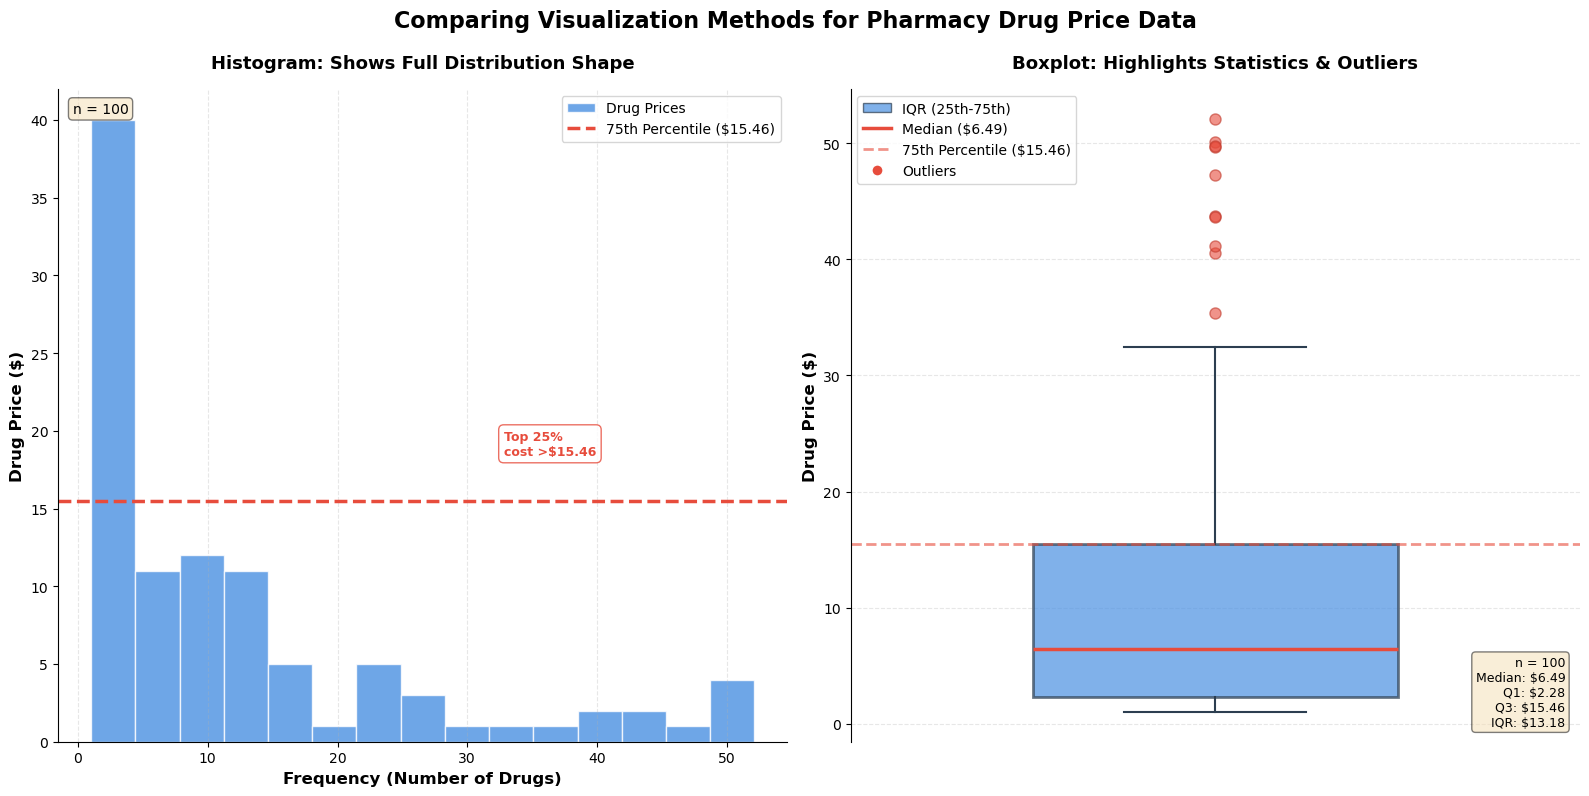


Visualization Comparison Summary:
Total drugs: 100
Median price: $6.49
75th percentile: $15.46
Top 25% of drugs cost: $15.46 or more


In [25]:
# Create side-by-side comparison with complete labels and legends
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Calculate statistics
percentile_75 = df['data'].quantile(0.75)
q1 = df['data'].quantile(0.25)
median = df['data'].median()
q3 = df['data'].quantile(0.75)

# Left: Enhanced Histogram (VERTICAL orientation)
ax1.hist(df['data'], bins=15, color='#4A90E2', edgecolor='white', alpha=0.8, 
         orientation='vertical', label='Drug Prices')
ax1.axhline(percentile_75, color='#E74C3C', linestyle='--', linewidth=2.5,
           label=f'75th Percentile (${percentile_75:.2f})')
ax1.set_ylabel('Drug Price ($)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Frequency (Number of Drugs)', fontsize=12, fontweight='bold')
ax1.set_title('Histogram: Shows Full Distribution Shape', fontsize=13, fontweight='bold', pad=15)
ax1.grid(axis='x', alpha=0.3, linestyle='--')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.legend(loc='upper right', fontsize=10)

# Add sample size annotation
ax1.text(0.02, 0.98, f'n = {len(df)}', transform=ax1.transAxes,
        fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Add text annotation for 75th percentile
ax1.text(ax1.get_xlim()[1] * 0.6, percentile_75 + 3, 
         f'Top 25%\ncost >${percentile_75:.2f}', 
         color='#E74C3C', fontsize=9, fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#E74C3C', alpha=0.8))

# Right: Enhanced Boxplot (VERTICAL)
bp = ax2.boxplot(df['data'], patch_artist=True, widths=0.5,
                 boxprops=dict(facecolor='#4A90E2', alpha=0.7, edgecolor='#2C3E50', linewidth=2),
                 medianprops=dict(color='#E74C3C', linewidth=2.5),
                 whiskerprops=dict(color='#2C3E50', linewidth=1.5),
                 capprops=dict(color='#2C3E50', linewidth=1.5),
                 flierprops=dict(marker='o', markerfacecolor='#E74C3C', markersize=8, 
                                markeredgecolor='#C0392B', alpha=0.6))

ax2.set_ylabel('Drug Price ($)', fontsize=12, fontweight='bold')
ax2.set_xlabel('', fontsize=12)
ax2.set_title('Boxplot: Highlights Statistics & Outliers', fontsize=13, fontweight='bold', pad=15)
ax2.set_xticks([])
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_visible(False)

# Add horizontal line at 75th percentile for comparison
ax2.axhline(percentile_75, color='#E74C3C', linestyle='--', linewidth=2, alpha=0.6,
           label=f'75th Percentile (${percentile_75:.2f})')

# Create custom legend entries for boxplot components
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

legend_elements = [
    Patch(facecolor='#4A90E2', alpha=0.7, edgecolor='#2C3E50', label='IQR (25th-75th)'),
    Line2D([0], [0], color='#E74C3C', linewidth=2.5, label=f'Median (${median:.2f})'),
    Line2D([0], [0], color='#E74C3C', linewidth=2, linestyle='--', alpha=0.6, 
           label=f'75th Percentile (${percentile_75:.2f})'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#E74C3C', 
           markersize=8, label='Outliers')
]
ax2.legend(handles=legend_elements, loc='upper left', fontsize=10)

# Add statistics text box
iqr = q3 - q1
stats_text = f'n = {len(df)}\nMedian: ${median:.2f}\nQ1: ${q1:.2f}\nQ3: ${q3:.2f}\nIQR: ${iqr:.2f}'
ax2.text(0.98, 0.02, stats_text, transform=ax2.transAxes,
        fontsize=9, verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Add main title
fig.suptitle('Comparing Visualization Methods for Pharmacy Drug Price Data', 
             fontsize=16, fontweight='bold', y=0.99)

plt.tight_layout()
plt.show()

# Print summary
print(f"\nVisualization Comparison Summary:")
print(f"{'='*50}")
print(f"Total drugs: {len(df)}")
print(f"Median price: ${median:.2f}")
print(f"75th percentile: ${percentile_75:.2f}")
print(f"Top 25% of drugs cost: ${q3:.2f} or more")

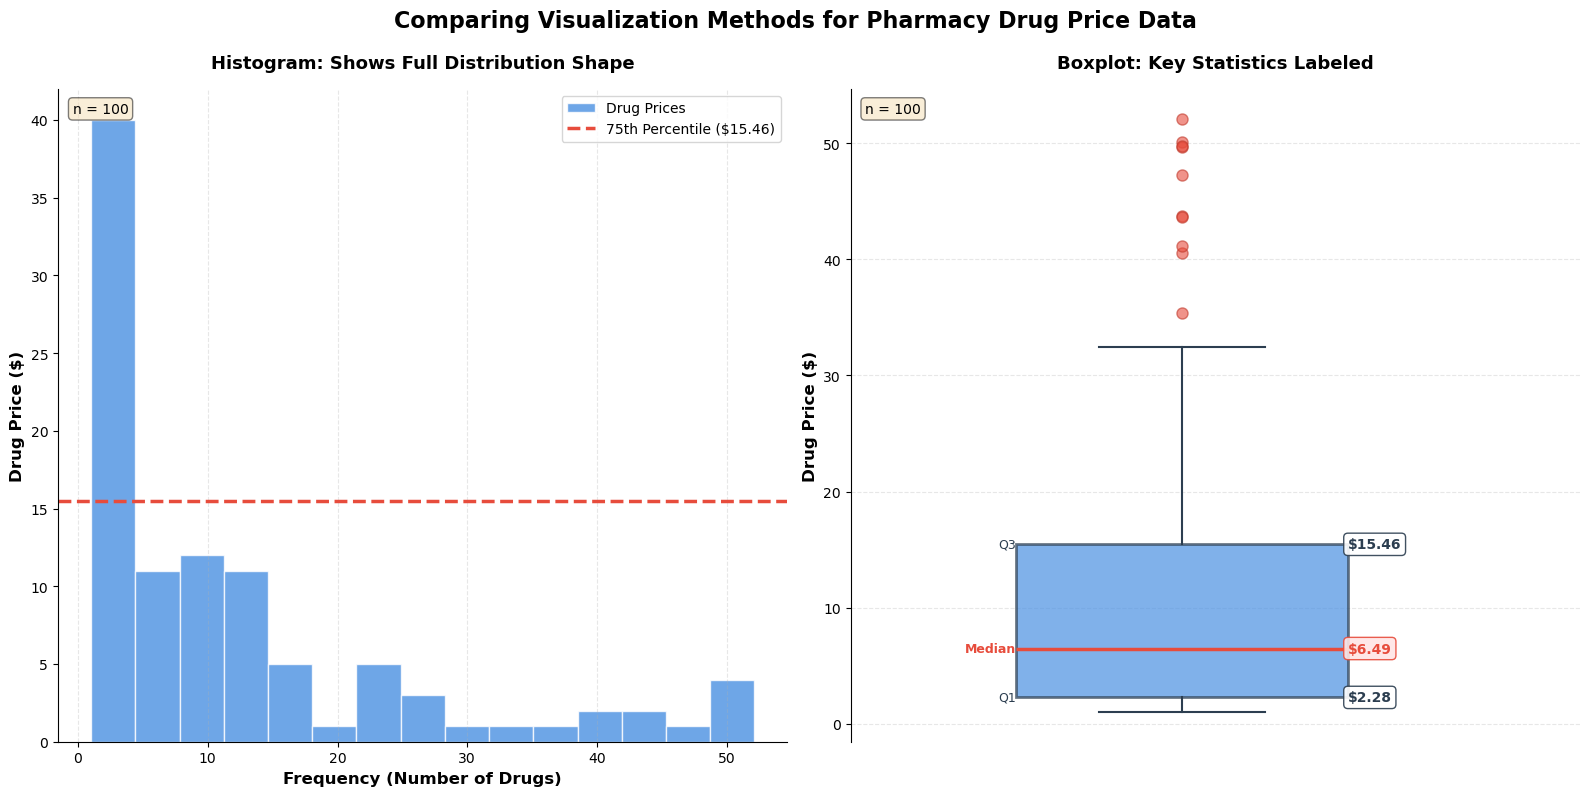


Key Price Points:
Q1 (bottom 25%):  $2.28
Median (middle):  $6.49
Q3 (top 25%):     $15.46 ← Expensive threshold


In [26]:
# Create side-by-side comparison with value labels on boxplot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Calculate statistics
percentile_75 = df['data'].quantile(0.75)
q1 = df['data'].quantile(0.25)
median = df['data'].median()
q3 = df['data'].quantile(0.75)
minimum = df['data'].min()
maximum = df['data'].max()

# Left: Enhanced Histogram (VERTICAL orientation)
ax1.hist(df['data'], bins=15, color='#4A90E2', edgecolor='white', alpha=0.8, 
         orientation='vertical', label='Drug Prices')
ax1.axhline(percentile_75, color='#E74C3C', linestyle='--', linewidth=2.5,
           label=f'75th Percentile (${percentile_75:.2f})')
ax1.set_ylabel('Drug Price ($)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Frequency (Number of Drugs)', fontsize=12, fontweight='bold')
ax1.set_title('Histogram: Shows Full Distribution Shape', fontsize=13, fontweight='bold', pad=15)
ax1.grid(axis='x', alpha=0.3, linestyle='--')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.legend(loc='upper right', fontsize=10)

# Add sample size annotation
ax1.text(0.02, 0.98, f'n = {len(df)}', transform=ax1.transAxes,
        fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Right: Enhanced Boxplot with VALUE LABELS
bp = ax2.boxplot(df['data'], patch_artist=True, widths=0.5,
                 boxprops=dict(facecolor='#4A90E2', alpha=0.7, edgecolor='#2C3E50', linewidth=2),
                 medianprops=dict(color='#E74C3C', linewidth=2.5),
                 whiskerprops=dict(color='#2C3E50', linewidth=1.5),
                 capprops=dict(color='#2C3E50', linewidth=1.5),
                 flierprops=dict(marker='o', markerfacecolor='#E74C3C', markersize=8, 
                                markeredgecolor='#C0392B', alpha=0.6))

# Add dollar value labels on the right side of boxplot lines
ax2.text(1.25, q1, f'${q1:.2f}', fontsize=10, va='center', ha='left',
        color='#2C3E50', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#2C3E50', alpha=0.9))

ax2.text(1.25, median, f'${median:.2f}', fontsize=10, va='center', ha='left',
        color='#E74C3C', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFE5E5', edgecolor='#E74C3C', alpha=0.9))

ax2.text(1.25, q3, f'${q3:.2f}', fontsize=10, va='center', ha='left',
        color='#2C3E50', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#2C3E50', alpha=0.9))

# Add descriptive labels on the left
ax2.text(0.75, q1, 'Q1', fontsize=9, va='center', ha='right', color='#2C3E50')
ax2.text(0.75, median, 'Median', fontsize=9, va='center', ha='right', color='#E74C3C', fontweight='bold')
ax2.text(0.75, q3, 'Q3', fontsize=9, va='center', ha='right', color='#2C3E50')

ax2.set_ylabel('Drug Price ($)', fontsize=12, fontweight='bold')
ax2.set_title('Boxplot: Key Statistics Labeled', fontsize=13, fontweight='bold', pad=15)
ax2.set_xticks([])
ax2.set_xlim(0.5, 1.6)  # Extend to accommodate labels
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_visible(False)

# Add sample size
ax2.text(0.02, 0.98, f'n = {len(df)}', transform=ax2.transAxes,
        fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Add main title
fig.suptitle('Comparing Visualization Methods for Pharmacy Drug Price Data', 
             fontsize=16, fontweight='bold', y=0.99)

plt.tight_layout()
plt.show()

# Print summary
print(f"\nKey Price Points:")
print(f"{'='*40}")
print(f"Q1 (bottom 25%):  ${q1:.2f}")
print(f"Median (middle):  ${median:.2f}")
print(f"Q3 (top 25%):     ${q3:.2f} ← Expensive threshold")

In [27]:
# IBM Anti Money Laundering Data
df = pd.read_csv('../../data/default_of_credit_card_clients.csv')
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

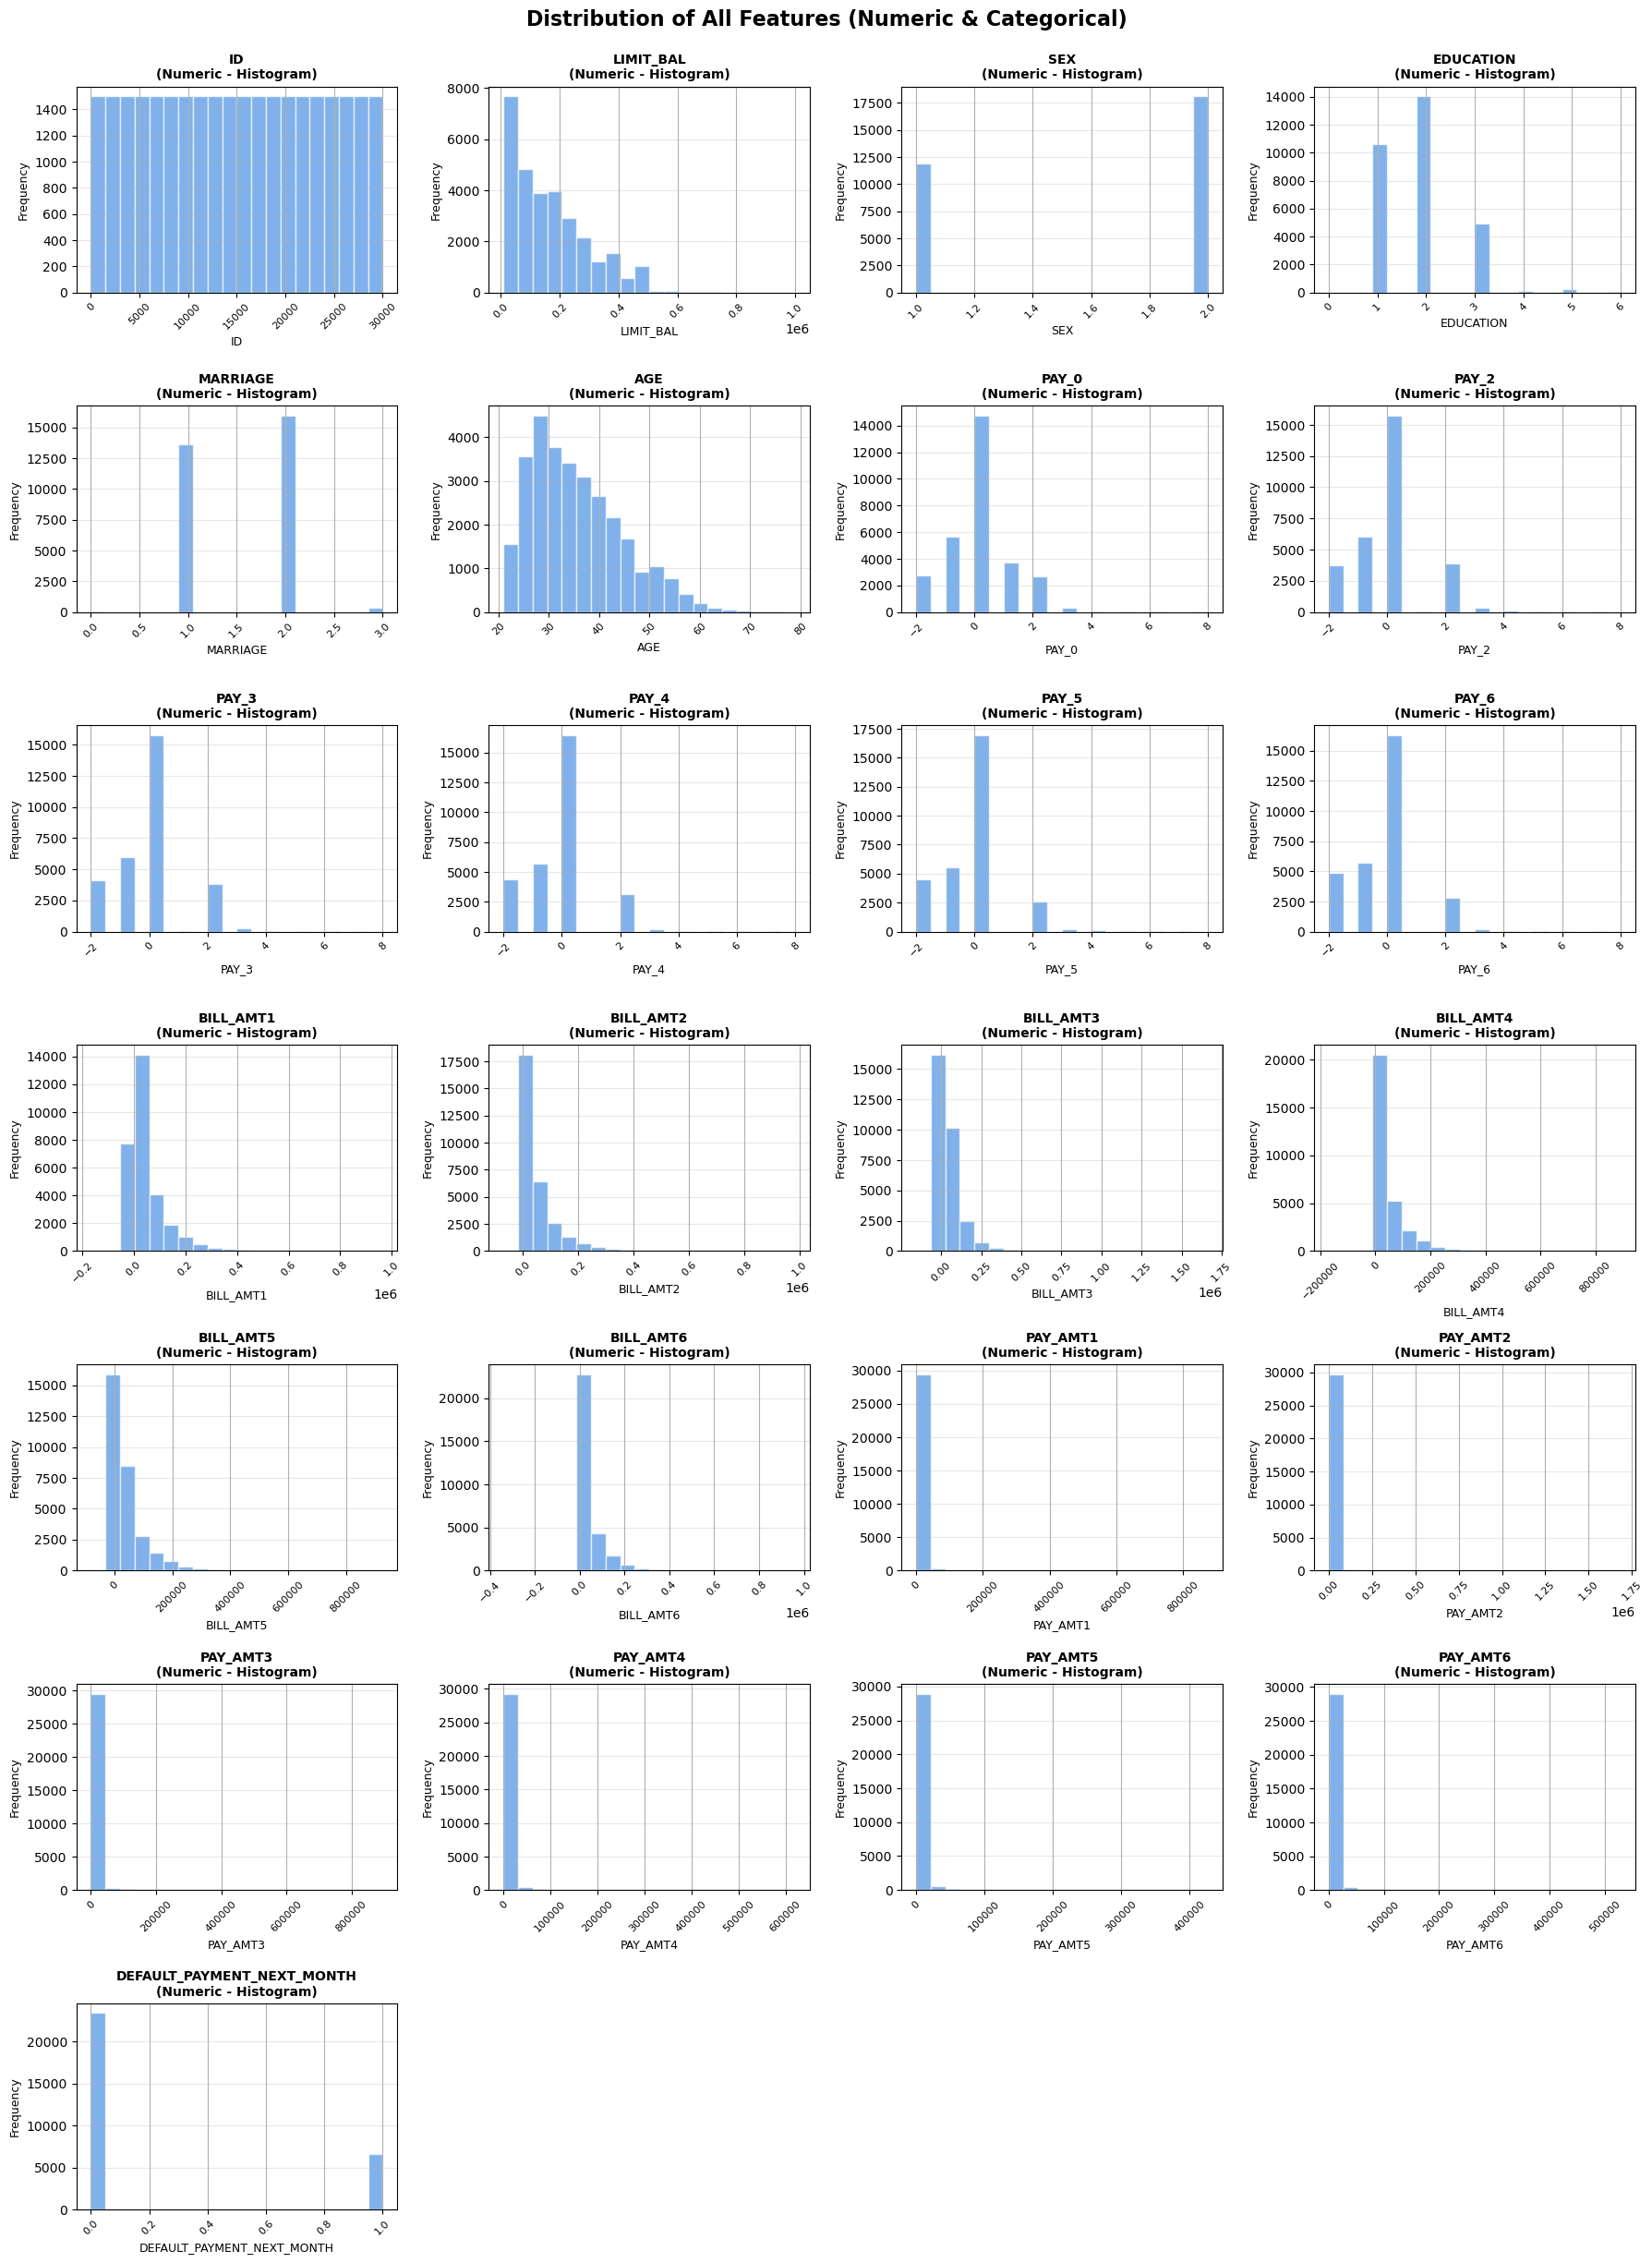

Total visualizations: 25
Numeric columns: 25
Categorical columns: 0


In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Separate numeric and categorical columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Calculate total plots needed
total_cols = len(numeric_cols) + len(categorical_cols)
n_cols = 4  # Number of columns in subplot grid
n_rows = int(np.ceil(total_cols / n_cols))

# Create figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5))
axes = axes.flatten()

# Plot numeric columns (Histograms)
for i, col in enumerate(numeric_cols):
    df[col].hist(bins=20, ax=axes[i], edgecolor='white', alpha=0.7, color='#4A90E2')
    axes[i].set_title(f'{col}\n(Numeric - Histogram)', fontsize=10, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=9)
    axes[i].set_ylabel('Frequency', fontsize=9)
    axes[i].grid(axis='y', alpha=0.3)
    axes[i].tick_params(axis='x', rotation=45, labelsize=8)

# Plot categorical columns (Bar plots)
for i, col in enumerate(categorical_cols):
    idx = len(numeric_cols) + i
    value_counts = df[col].value_counts()
    
    # Limit to top 10 categories if too many
    if len(value_counts) > 10:
        value_counts = value_counts.head(10)
        title_suffix = f'\n(Categorical - Top 10)'
    else:
        title_suffix = f'\n(Categorical)'
    
    value_counts.plot(kind='bar', ax=axes[idx], color='#E74C3C', alpha=0.7, edgecolor='white')
    axes[idx].set_title(f'{col}{title_suffix}', fontsize=10, fontweight='bold')
    axes[idx].set_xlabel(col, fontsize=9)
    axes[idx].set_ylabel('Count', fontsize=9)
    axes[idx].grid(axis='y', alpha=0.3)
    axes[idx].tick_params(axis='x', rotation=45, labelsize=8)

# Hide extra subplots
for i in range(total_cols, len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Distribution of All Features (Numeric & Categorical)', 
             fontsize=16, fontweight='bold', y=0.998)
plt.tight_layout()
plt.show()

print(f"Total visualizations: {total_cols}")
print(f"Numeric columns: {len(numeric_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")

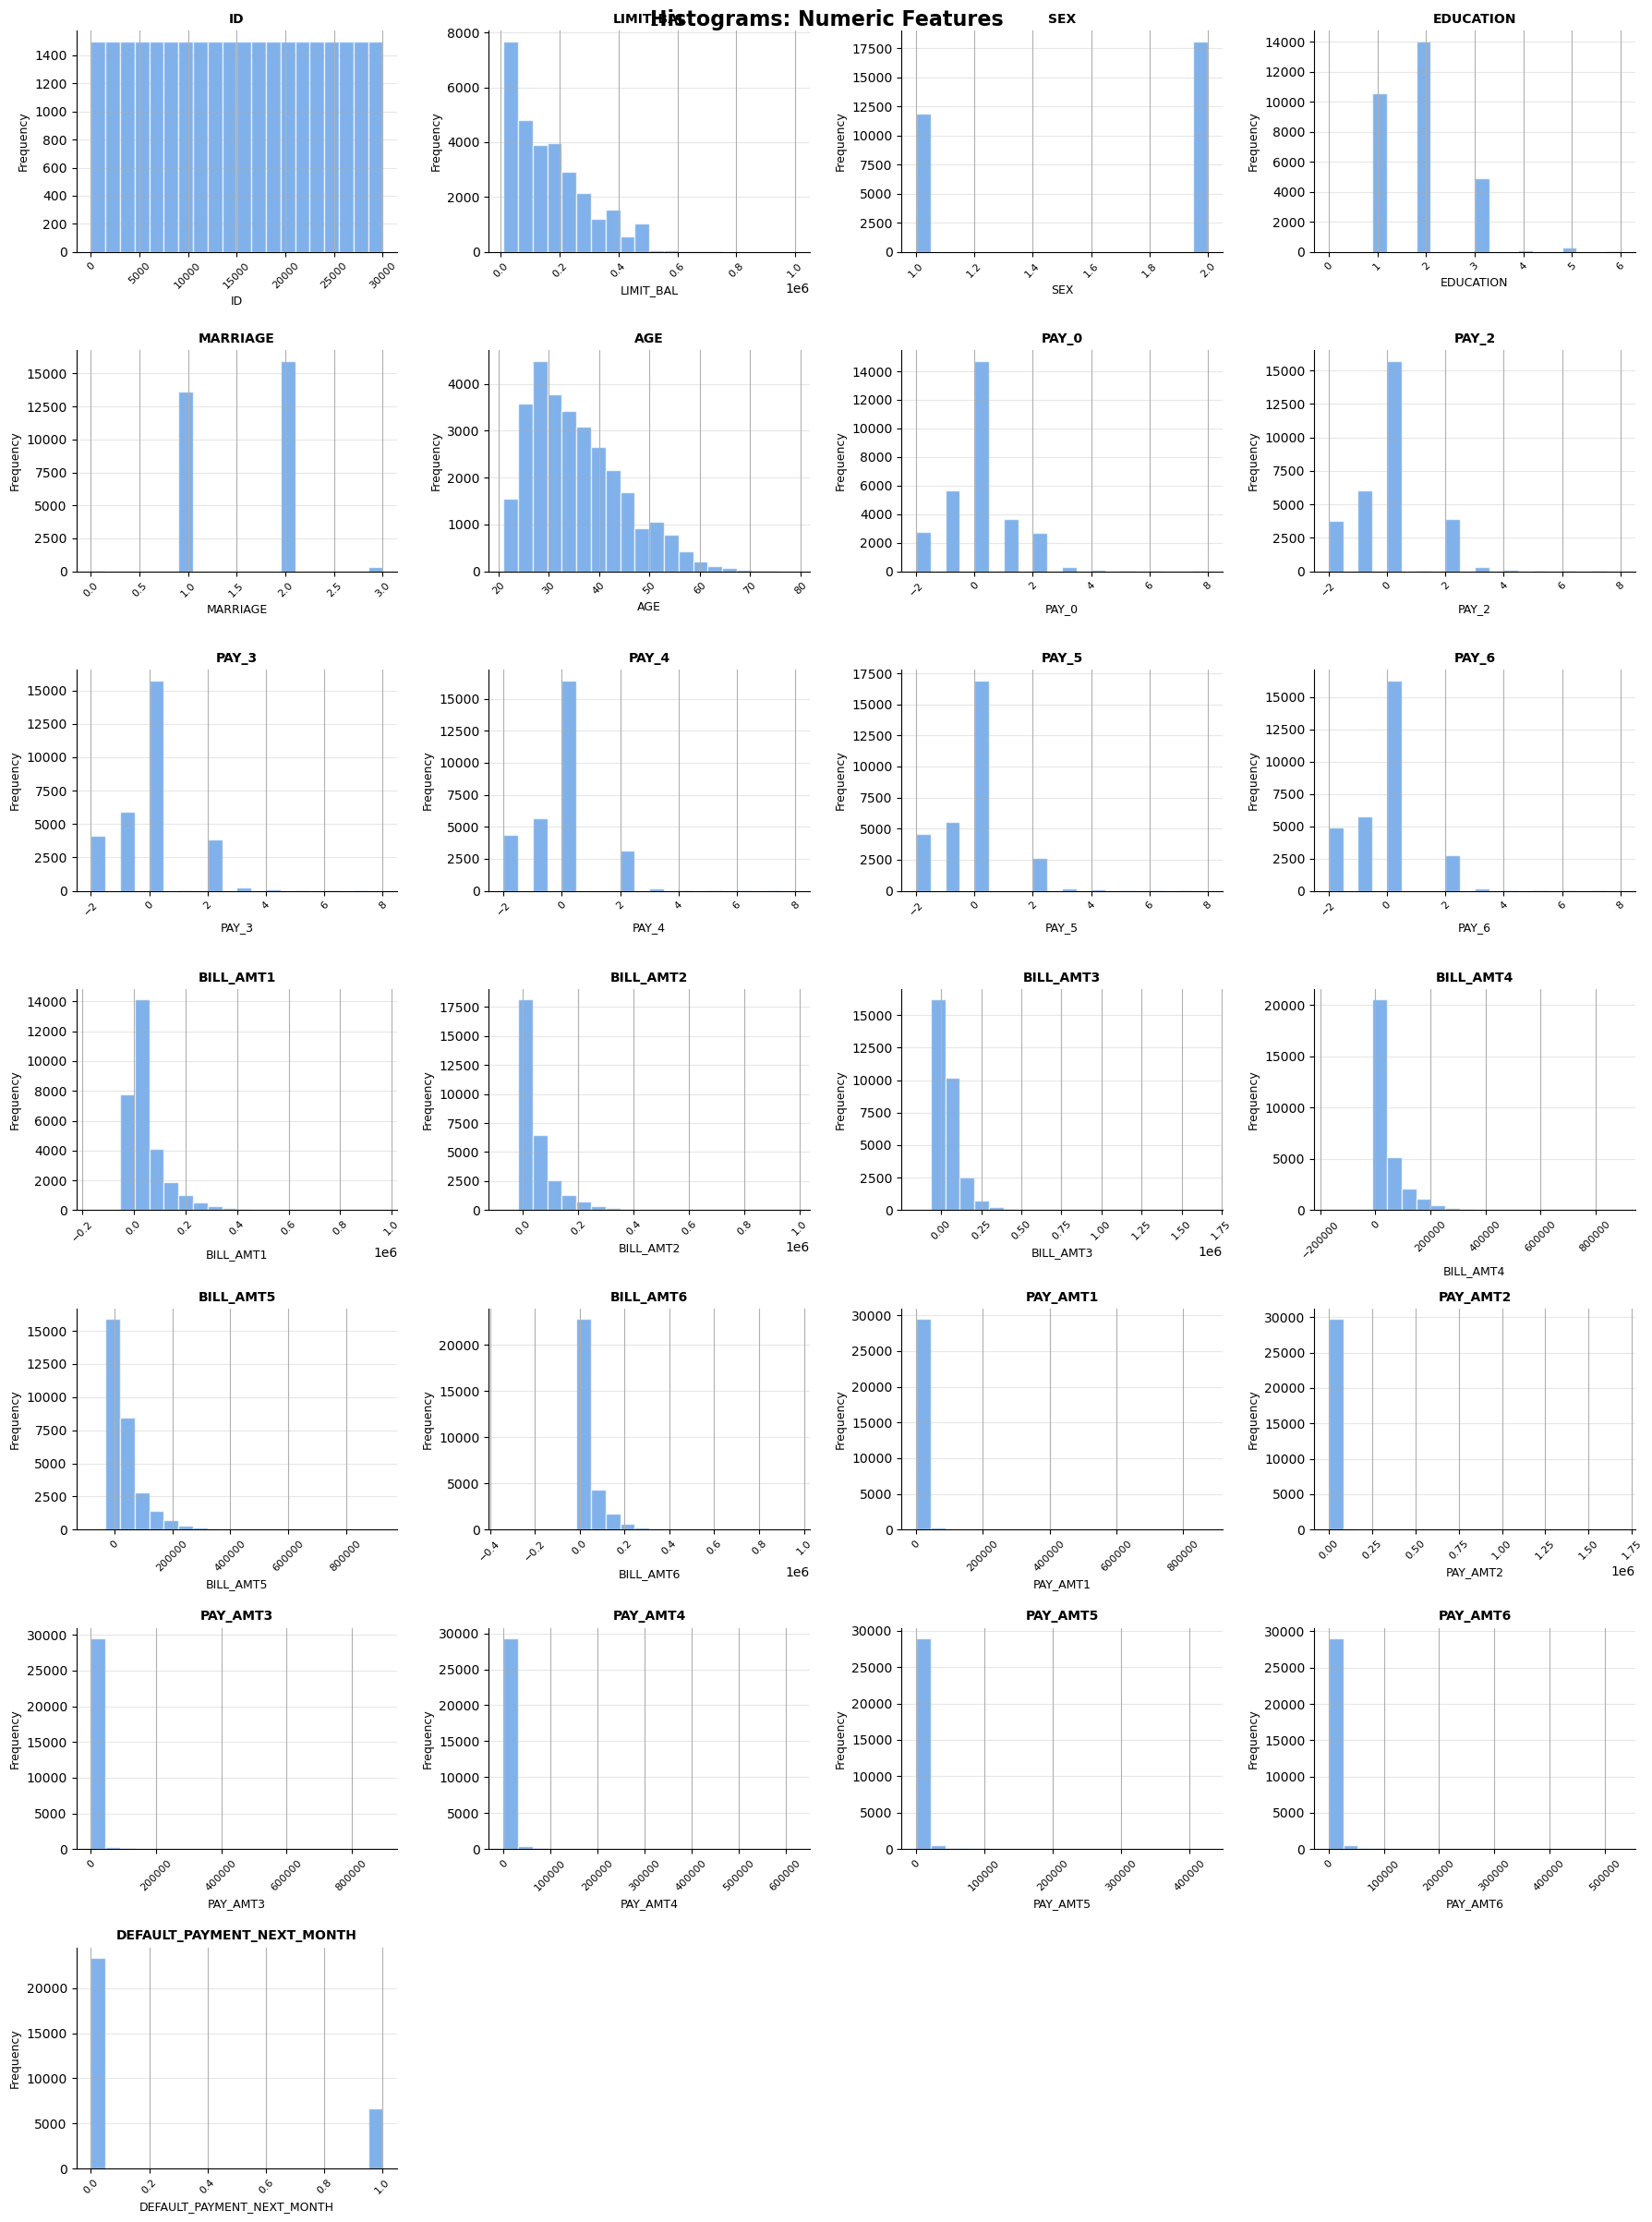


Summary:
Numeric columns (25): ['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'DEFAULT_PAYMENT_NEXT_MONTH']
Categorical columns (0): []


In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Separate columns by type
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# ===== NUMERIC COLUMNS (Histograms) =====
if len(numeric_cols) > 0:
    n_cols_num = 4
    n_rows_num = int(np.ceil(len(numeric_cols) / n_cols_num))
    
    fig1, axes1 = plt.subplots(n_rows_num, n_cols_num, figsize=(18, n_rows_num * 3.5))
    axes1 = axes1.flatten() if len(numeric_cols) > 1 else [axes1]
    
    for i, col in enumerate(numeric_cols):
        df[col].hist(bins=20, ax=axes1[i], edgecolor='white', alpha=0.7, color='#4A90E2')
        axes1[i].set_title(f'{col}', fontsize=10, fontweight='bold')
        axes1[i].set_xlabel(col, fontsize=9)
        axes1[i].set_ylabel('Frequency', fontsize=9)
        axes1[i].grid(axis='y', alpha=0.3)
        axes1[i].tick_params(axis='x', rotation=45, labelsize=8)
        axes1[i].spines['top'].set_visible(False)
        axes1[i].spines['right'].set_visible(False)
    
    # Hide extra subplots
    for i in range(len(numeric_cols), len(axes1)):
        axes1[i].set_visible(False)
    
    plt.suptitle('Histograms: Numeric Features', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# ===== CATEGORICAL COLUMNS (Bar Plots) =====
if len(categorical_cols) > 0:
    n_cols_cat = 3
    n_rows_cat = int(np.ceil(len(categorical_cols) / n_cols_cat))
    
    fig2, axes2 = plt.subplots(n_rows_cat, n_cols_cat, figsize=(18, n_rows_cat * 4))
    axes2 = axes2.flatten() if len(categorical_cols) > 1 else [axes2]
    
    for i, col in enumerate(categorical_cols):
        value_counts = df[col].value_counts()
        
        # Limit to top 15 categories
        if len(value_counts) > 15:
            value_counts = value_counts.head(15)
            title = f'{col} (Top 15 categories)'
        else:
            title = f'{col}'
        
        value_counts.plot(kind='bar', ax=axes2[i], color='#E74C3C', 
                         alpha=0.7, edgecolor='white')
        axes2[i].set_title(title, fontsize=10, fontweight='bold')
        axes2[i].set_xlabel('Category', fontsize=9)
        axes2[i].set_ylabel('Count', fontsize=9)
        axes2[i].grid(axis='y', alpha=0.3)
        axes2[i].tick_params(axis='x', rotation=45, labelsize=8)
        axes2[i].spines['top'].set_visible(False)
        axes2[i].spines['right'].set_visible(False)
    
    # Hide extra subplots
    for i in range(len(categorical_cols), len(axes2)):
        axes2[i].set_visible(False)
    
    plt.suptitle('Bar Plots: Categorical Features', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

print(f"\nSummary:")
print(f"Numeric columns ({len(numeric_cols)}): {numeric_cols}")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")

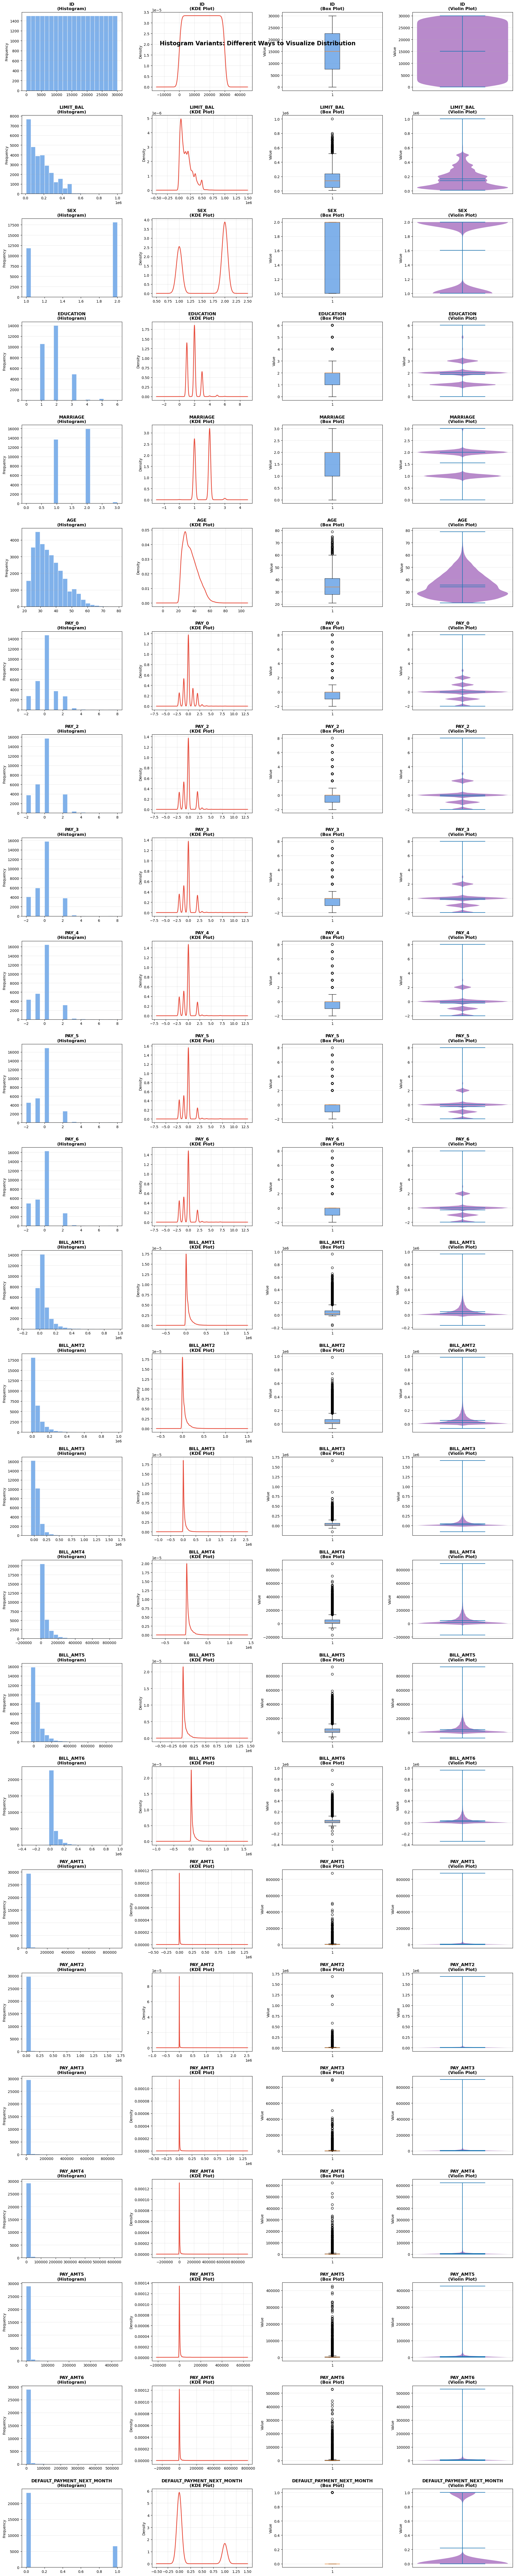

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Pick a few interesting columns to demonstrate variants
demo_cols = df.columns.tolist()  # Adjust to your columns

fig, axes = plt.subplots(len(demo_cols), 4, figsize=(20, len(demo_cols) * 4))

for i, col in enumerate(demo_cols):
    # 1. Standard Histogram
    axes[i, 0].hist(df[col], bins=20, edgecolor='white', alpha=0.7, color='#4A90E2')
    axes[i, 0].set_title(f'{col}\n(Histogram)', fontweight='bold')
    axes[i, 0].set_ylabel('Frequency')
    axes[i, 0].grid(axis='y', alpha=0.3)
    
    # 2. KDE Plot (Kernel Density Estimate)
    df[col].plot.kde(ax=axes[i, 1], color='#E74C3C', linewidth=2)
    axes[i, 1].set_title(f'{col}\n(KDE Plot)', fontweight='bold')
    axes[i, 1].set_ylabel('Density')
    axes[i, 1].grid(alpha=0.3)
    
    # 3. Box Plot
    axes[i, 2].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                       boxprops=dict(facecolor='#4A90E2', alpha=0.7))
    axes[i, 2].set_title(f'{col}\n(Box Plot)', fontweight='bold')
    axes[i, 2].set_ylabel('Value')
    axes[i, 2].grid(axis='y', alpha=0.3)
    
    # 4. Violin Plot
    parts = axes[i, 3].violinplot([df[col].dropna()], positions=[0], 
                                   showmeans=True, showmedians=True)
    for pc in parts['bodies']:
        pc.set_facecolor('#9B59B6')
        pc.set_alpha(0.7)
    axes[i, 3].set_title(f'{col}\n(Violin Plot)', fontweight='bold')
    axes[i, 3].set_ylabel('Value')
    axes[i, 3].grid(axis='y', alpha=0.3)
    axes[i, 3].set_xticks([])

plt.suptitle('Histogram Variants: Different Ways to Visualize Distribution', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

/Users/gaurav/miniconda3/envs/stocks3/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 39.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


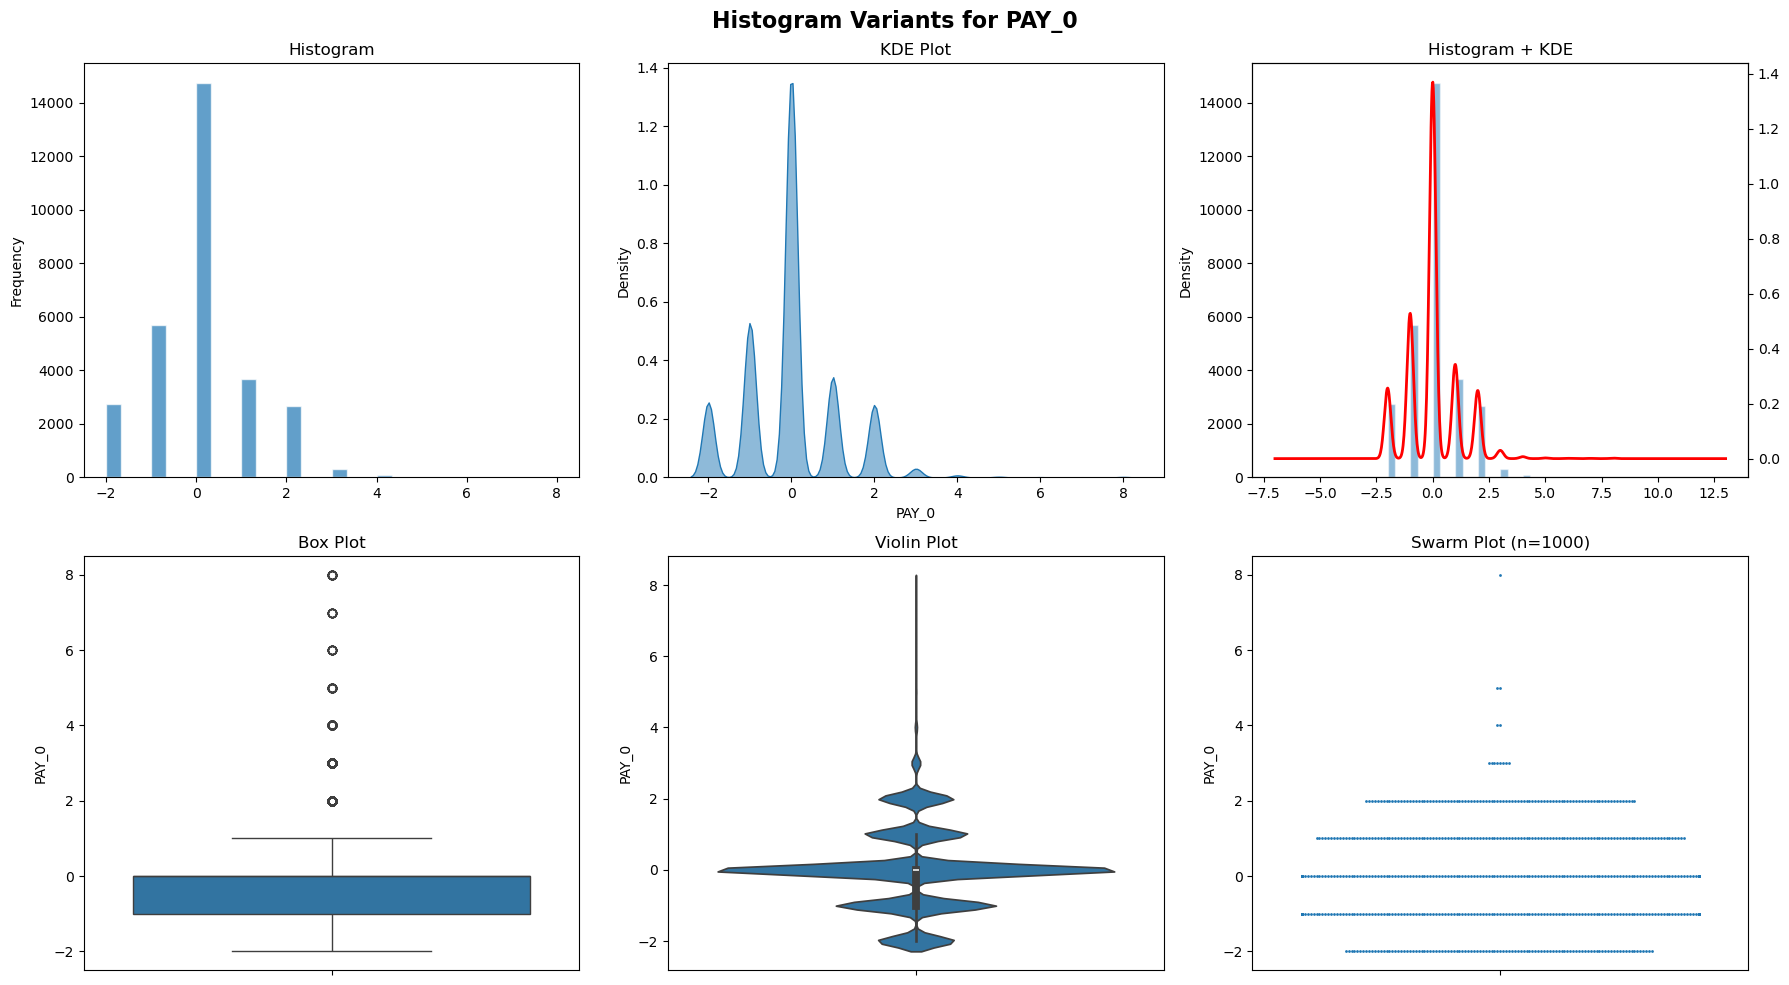

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select a column to demonstrate
col = 'PAY_0'  # Change to any column

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Histogram
axes[0, 0].hist(df[col], bins=30, edgecolor='white', alpha=0.7)
axes[0, 0].set_title('Histogram')
axes[0, 0].set_ylabel('Frequency')

# 2. KDE Plot
sns.kdeplot(data=df, x=col, ax=axes[0, 1], fill=True, alpha=0.5)
axes[0, 1].set_title('KDE Plot')

# 3. Histogram + KDE Combined
df[col].plot.hist(bins=30, ax=axes[0, 2], alpha=0.5, edgecolor='white')
df[col].plot.kde(ax=axes[0, 2], secondary_y=True, color='red', linewidth=2)
axes[0, 2].set_title('Histogram + KDE')

# 4. Box Plot
sns.boxplot(data=df, y=col, ax=axes[1, 0])
axes[1, 0].set_title('Box Plot')

# 5. Violin Plot
sns.violinplot(data=df, y=col, ax=axes[1, 1])
axes[1, 1].set_title('Violin Plot')

# 6. Swarm Plot (use sample if dataset is large)
sample_size = min(1000, len(df))
df_sample = df.sample(n=sample_size, random_state=42)
sns.swarmplot(data=df_sample, y=col, ax=axes[1, 2], size=2)
axes[1, 2].set_title(f'Swarm Plot (n={sample_size})')

plt.suptitle(f'Histogram Variants for {col}', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

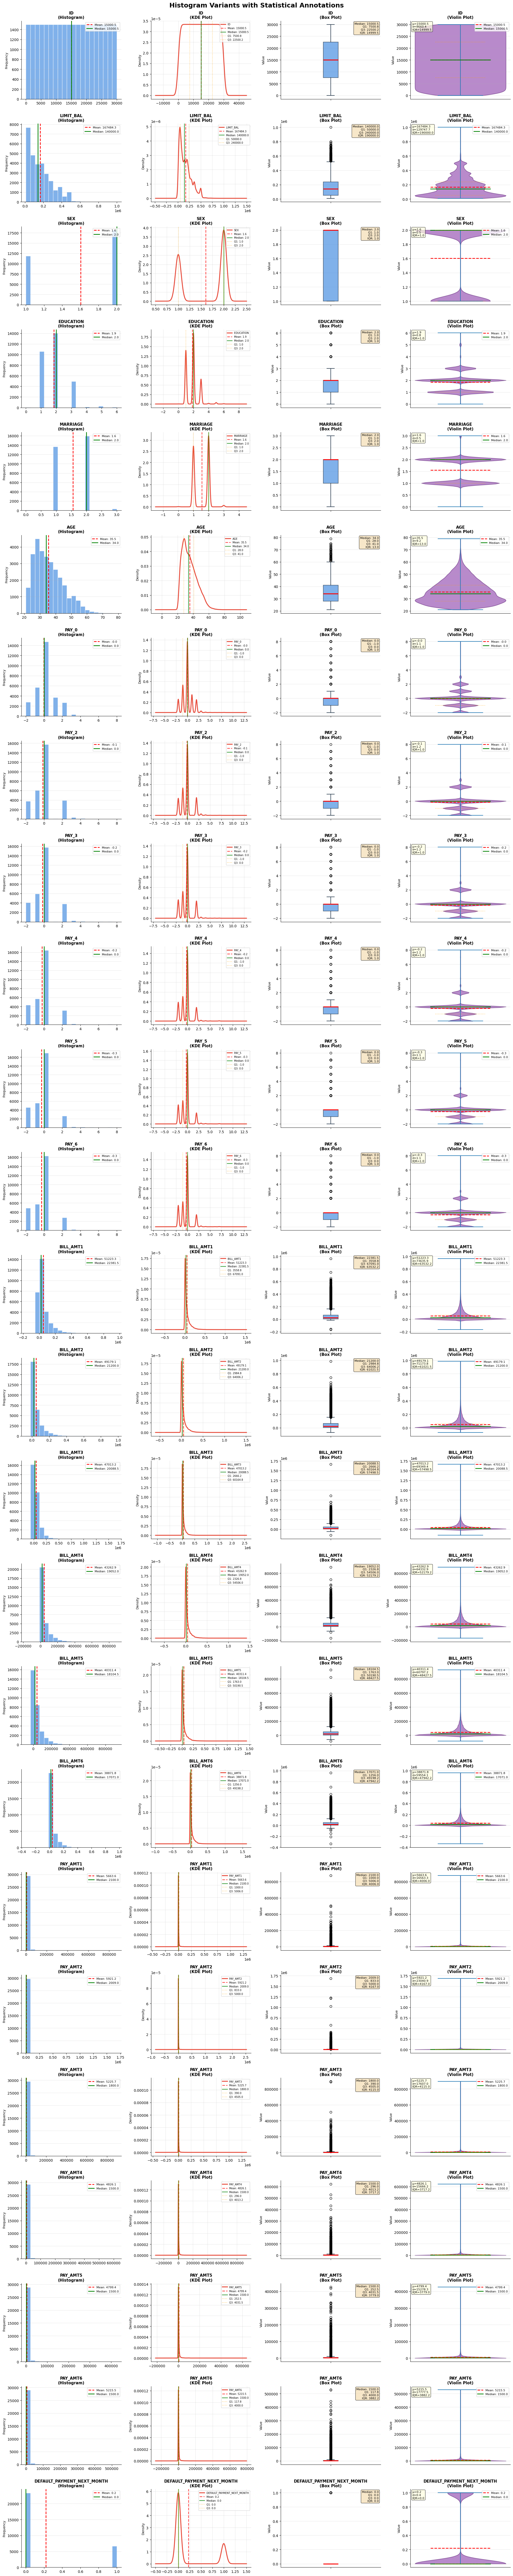


Summary Statistics:

ID:
  Mean: 15000.50
  Median: 15000.50
  Std Dev: 8660.40
  Q1: 7500.75
  Q3: 22500.25
  IQR: 14999.50

LIMIT_BAL:
  Mean: 167484.32
  Median: 140000.00
  Std Dev: 129747.66
  Q1: 50000.00
  Q3: 240000.00
  IQR: 190000.00

SEX:
  Mean: 1.60
  Median: 2.00
  Std Dev: 0.49
  Q1: 1.00
  Q3: 2.00
  IQR: 1.00

EDUCATION:
  Mean: 1.85
  Median: 2.00
  Std Dev: 0.79
  Q1: 1.00
  Q3: 2.00
  IQR: 1.00

MARRIAGE:
  Mean: 1.55
  Median: 2.00
  Std Dev: 0.52
  Q1: 1.00
  Q3: 2.00
  IQR: 1.00

AGE:
  Mean: 35.49
  Median: 34.00
  Std Dev: 9.22
  Q1: 28.00
  Q3: 41.00
  IQR: 13.00

PAY_0:
  Mean: -0.02
  Median: 0.00
  Std Dev: 1.12
  Q1: -1.00
  Q3: 0.00
  IQR: 1.00

PAY_2:
  Mean: -0.13
  Median: 0.00
  Std Dev: 1.20
  Q1: -1.00
  Q3: 0.00
  IQR: 1.00

PAY_3:
  Mean: -0.17
  Median: 0.00
  Std Dev: 1.20
  Q1: -1.00
  Q3: 0.00
  IQR: 1.00

PAY_4:
  Mean: -0.22
  Median: 0.00
  Std Dev: 1.17
  Q1: -1.00
  Q3: 0.00
  IQR: 1.00

PAY_5:
  Mean: -0.27
  Median: 0.00
  Std Dev: 1.1

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Pick columns to demonstrate
# demo_cols = ['X1', 'X2', 'X3', 'X4']  # Adjust to your columns

fig, axes = plt.subplots(len(demo_cols), 4, figsize=(20, len(demo_cols) * 4))

for i, col in enumerate(demo_cols):
    # Calculate statistics
    mean_val = df[col].mean()
    median_val = df[col].median()
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    std_val = df[col].std()
    
    # 1. HISTOGRAM with Mean and Median
    axes[i, 0].hist(df[col], bins=20, edgecolor='white', alpha=0.7, color='#4A90E2')
    axes[i, 0].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.1f}')
    axes[i, 0].axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.1f}')
    axes[i, 0].set_title(f'{col}\n(Histogram)', fontweight='bold', fontsize=11)
    axes[i, 0].set_ylabel('Frequency', fontsize=9)
    axes[i, 0].grid(axis='y', alpha=0.3)
    axes[i, 0].legend(loc='upper right', fontsize=8)
    axes[i, 0].spines['top'].set_visible(False)
    axes[i, 0].spines['right'].set_visible(False)
    
    # 2. KDE PLOT with Mean, Median, and Quartiles
    df[col].plot.kde(ax=axes[i, 1], color='#E74C3C', linewidth=2.5)
    axes[i, 1].axvline(mean_val, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Mean: {mean_val:.1f}')
    axes[i, 1].axvline(median_val, color='green', linestyle='-', linewidth=2, alpha=0.7, label=f'Median: {median_val:.1f}')
    axes[i, 1].axvline(q1, color='orange', linestyle=':', linewidth=1.5, alpha=0.6, label=f'Q1: {q1:.1f}')
    axes[i, 1].axvline(q3, color='orange', linestyle=':', linewidth=1.5, alpha=0.6, label=f'Q3: {q3:.1f}')
    axes[i, 1].set_title(f'{col}\n(KDE Plot)', fontweight='bold', fontsize=11)
    axes[i, 1].set_ylabel('Density', fontsize=9)
    axes[i, 1].grid(alpha=0.3)
    axes[i, 1].legend(loc='upper right', fontsize=7)
    axes[i, 1].spines['top'].set_visible(False)
    axes[i, 1].spines['right'].set_visible(False)
    
    # 3. BOX PLOT with Labeled Statistics
    bp = axes[i, 2].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                            boxprops=dict(facecolor='#4A90E2', alpha=0.7, edgecolor='#2C3E50', linewidth=1.5),
                            whiskerprops=dict(color='#2C3E50', linewidth=1.5),
                            capprops=dict(color='#2C3E50', linewidth=1.5),
                            medianprops=dict(color='red', linewidth=2.5))
    axes[i, 2].set_title(f'{col}\n(Box Plot)', fontweight='bold', fontsize=11)
    axes[i, 2].set_ylabel('Value', fontsize=9)
    axes[i, 2].grid(axis='y', alpha=0.3)
    axes[i, 2].set_xticklabels([''])
    axes[i, 2].spines['top'].set_visible(False)
    axes[i, 2].spines['right'].set_visible(False)
    
    # Add text annotations for box plot statistics
    stats_text = f'Median: {median_val:.1f}\nQ1: {q1:.1f}\nQ3: {q3:.1f}\nIQR: {iqr:.1f}'
    axes[i, 2].text(0.98, 0.98, stats_text, transform=axes[i, 2].transAxes,
                   fontsize=8, verticalalignment='top', horizontalalignment='right',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
    
    # 4. VIOLIN PLOT with Mean and Median lines
    parts = axes[i, 3].violinplot([df[col].dropna()], positions=[0], 
                                  showmeans=False, showmedians=False)
    for pc in parts['bodies']:
        pc.set_facecolor('#9B59B6')
        pc.set_alpha(0.7)
        pc.set_edgecolor('#6C3483')
        pc.set_linewidth(1.5)
    
    # Add horizontal lines for mean and median
    axes[i, 3].axhline(mean_val, color='red', linestyle='--', linewidth=2, 
                      xmin=0.2, xmax=0.8, label=f'Mean: {mean_val:.1f}')
    axes[i, 3].axhline(median_val, color='green', linestyle='-', linewidth=2, 
                      xmin=0.2, xmax=0.8, label=f'Median: {median_val:.1f}')
    axes[i, 3].axhline(q1, color='orange', linestyle=':', linewidth=1.5, 
                      xmin=0.25, xmax=0.75, alpha=0.6)
    axes[i, 3].axhline(q3, color='orange', linestyle=':', linewidth=1.5, 
                      xmin=0.25, xmax=0.75, alpha=0.6)
    
    axes[i, 3].set_title(f'{col}\n(Violin Plot)', fontweight='bold', fontsize=11)
    axes[i, 3].set_ylabel('Value', fontsize=9)
    axes[i, 3].grid(axis='y', alpha=0.3)
    axes[i, 3].set_xticks([])
    axes[i, 3].legend(loc='upper right', fontsize=8)
    axes[i, 3].spines['top'].set_visible(False)
    axes[i, 3].spines['right'].set_visible(False)
    
    # Add statistics summary text
    summary_text = f'μ={mean_val:.1f}\nσ={std_val:.1f}\nIQR={iqr:.1f}'
    axes[i, 3].text(0.02, 0.98, summary_text, transform=axes[i, 3].transAxes,
                   fontsize=8, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

plt.suptitle('Histogram Variants with Statistical Annotations', 
             fontsize=18, fontweight='bold', y=0.998)
plt.tight_layout()
plt.show()

# Print summary statistics
print("\nSummary Statistics:")
print("="*80)
for col in demo_cols:
    print(f"\n{col}:")
    print(f"  Mean: {df[col].mean():.2f}")
    print(f"  Median: {df[col].median():.2f}")
    print(f"  Std Dev: {df[col].std():.2f}")
    print(f"  Q1: {df[col].quantile(0.25):.2f}")
    print(f"  Q3: {df[col].quantile(0.75):.2f}")
    print(f"  IQR: {df[col].quantile(0.75) - df[col].quantile(0.25):.2f}")

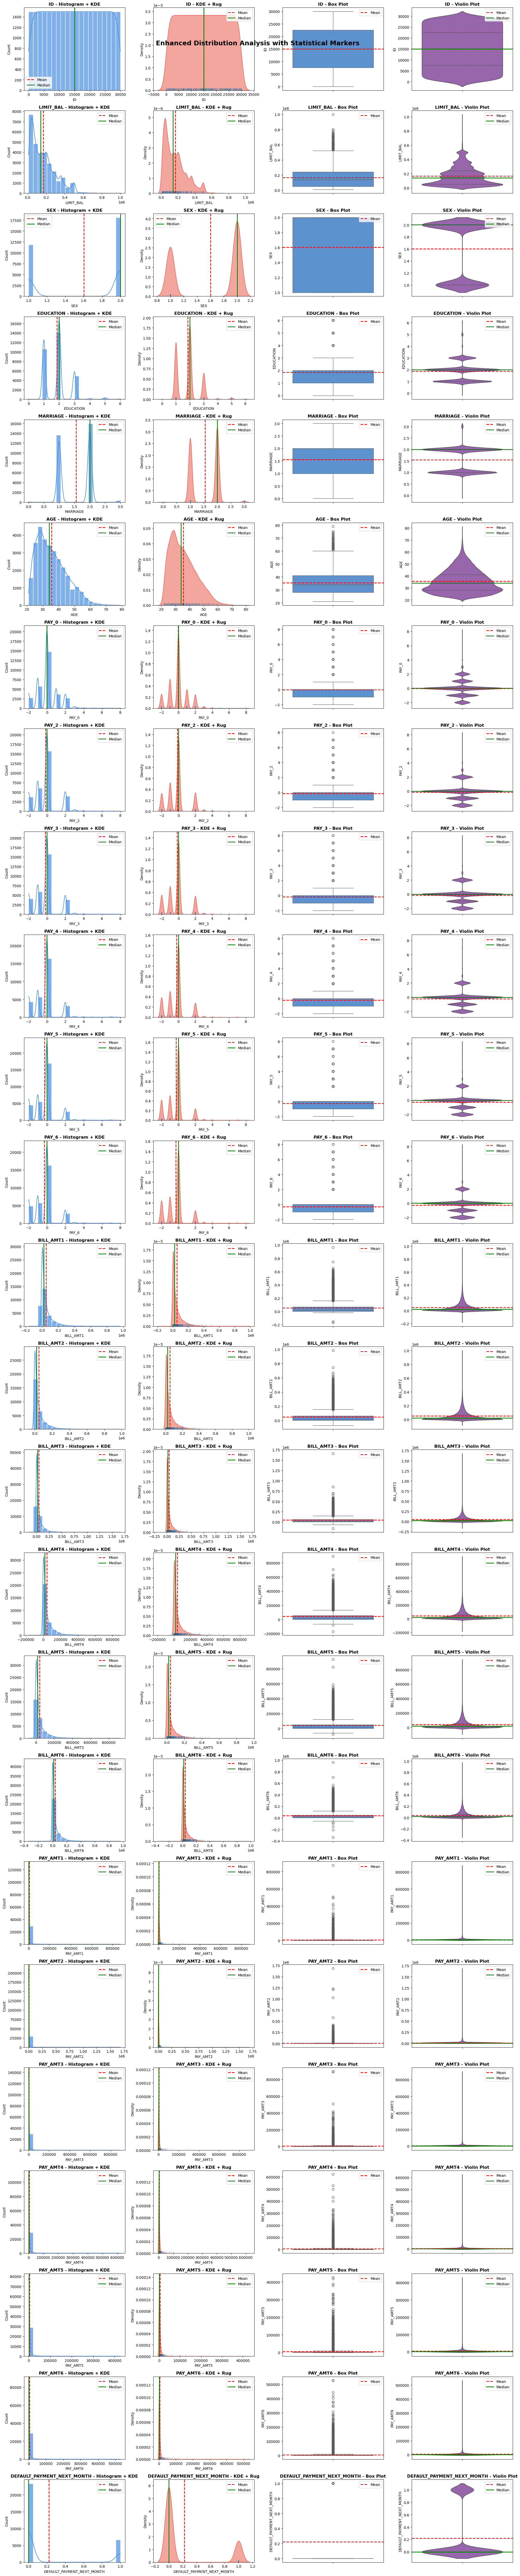

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select columns to demonstrate
# demo_cols = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'PAY_AMT1']

fig, axes = plt.subplots(len(demo_cols), 4, figsize=(20, len(demo_cols) * 4))

for i, col in enumerate(demo_cols):
    mean_val = df[col].mean()
    median_val = df[col].median()
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    
    # 1. Histogram with KDE overlay and statistics
    sns.histplot(data=df, x=col, bins=20, kde=True, ax=axes[i, 0], 
                color='#4A90E2', alpha=0.7, edgecolor='white')
    axes[i, 0].axvline(mean_val, color='red', linestyle='--', linewidth=2, label='Mean')
    axes[i, 0].axvline(median_val, color='green', linestyle='-', linewidth=2, label='Median')
    axes[i, 0].set_title(f'{col} - Histogram + KDE', fontweight='bold')
    axes[i, 0].legend()
    
    # 2. KDE with rug plot
    sns.kdeplot(data=df, x=col, ax=axes[i, 1], fill=True, alpha=0.5, color='#E74C3C')
    sns.rugplot(data=df.sample(min(500, len(df))), x=col, ax=axes[i, 1], alpha=0.3)
    axes[i, 1].axvline(mean_val, color='red', linestyle='--', linewidth=2, label='Mean')
    axes[i, 1].axvline(median_val, color='green', linestyle='-', linewidth=2, label='Median')
    axes[i, 1].set_title(f'{col} - KDE + Rug', fontweight='bold')
    axes[i, 1].legend()
    
    # 3. Enhanced Box Plot
    sns.boxplot(data=df, y=col, ax=axes[i, 2], color='#4A90E2')
    axes[i, 2].axhline(mean_val, color='red', linestyle='--', linewidth=2, label='Mean')
    axes[i, 2].set_title(f'{col} - Box Plot', fontweight='bold')
    axes[i, 2].legend(loc='upper right')
    
    # 4. Violin Plot with statistics
    sns.violinplot(data=df, y=col, ax=axes[i, 3], color='#9B59B6', inner='quartile')
    axes[i, 3].axhline(mean_val, color='red', linestyle='--', linewidth=2, label='Mean')
    axes[i, 3].axhline(median_val, color='green', linestyle='-', linewidth=2, label='Median')
    axes[i, 3].set_title(f'{col} - Violin Plot', fontweight='bold')
    axes[i, 3].legend(loc='upper right')

plt.suptitle('Enhanced Distribution Analysis with Statistical Markers', 
             fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

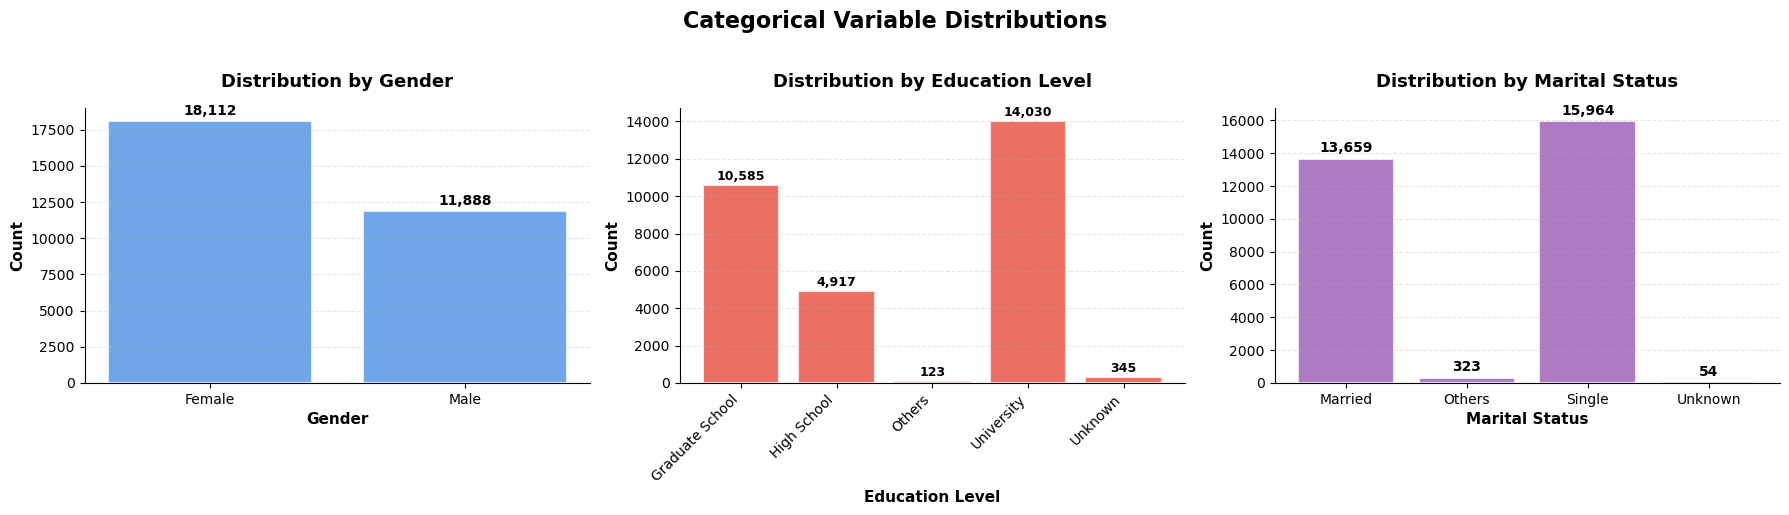

Categorical Variable Summary:

Gender Distribution:
SEX
Female    18112
Male      11888
Name: count, dtype: int64

Education Distribution:
EDUCATION
Graduate School    10585
High School         4917
Others               123
University         14030
Unknown              345
Name: count, dtype: int64

Marital Status Distribution:
MARRIAGE
Married    13659
Others       323
Single     15964
Unknown       54
Name: count, dtype: int64


In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# Create a copy of the dataframe for visualization
df_display = df.copy()

# Map numeric values to categorical labels
# Based on UCI Credit Card Default dataset documentation

# SEX: 1 = Male, 2 = Female
df_display['SEX'] = df['SEX'].map({
    1: 'Male',
    2: 'Female'
})

# EDUCATION: 1 = Graduate school, 2 = University, 3 = High school, 4 = Others
df_display['EDUCATION'] = df['EDUCATION'].map({
    1: 'Graduate School',
    2: 'University',
    3: 'High School',
    4: 'Others',
    5: 'Unknown',  # Sometimes there are values 5, 6, 0
    6: 'Unknown',
    0: 'Unknown'
})

# MARRIAGE: 1 = Married, 2 = Single, 3 = Others
df_display['MARRIAGE'] = df['MARRIAGE'].map({
    1: 'Married',
    2: 'Single',
    3: 'Others',
    0: 'Unknown'  # Sometimes there's 0
})

# Create bar plots for categorical variables
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# SEX
sex_counts = df_display['SEX'].value_counts()
axes[0].bar(sex_counts.index, sex_counts.values, color='#4A90E2', alpha=0.8, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribution by Gender', fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel('Gender', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=11, fontweight='bold')
axes[0].tick_params(axis='x', rotation=0, labelsize=10)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
# Add value labels on bars
for i, (idx, val) in enumerate(zip(sex_counts.index, sex_counts.values)):
    axes[0].text(i, val + 200, f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# EDUCATION
edu_counts = df_display['EDUCATION'].value_counts().sort_index()
axes[1].bar(range(len(edu_counts)), edu_counts.values, color='#E74C3C', alpha=0.8, edgecolor='white', linewidth=1.5)
axes[1].set_xticks(range(len(edu_counts)))
axes[1].set_xticklabels(edu_counts.index, rotation=45, ha='right')
axes[1].set_title('Distribution by Education Level', fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel('Education Level', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Count', fontsize=11, fontweight='bold')
axes[1].tick_params(labelsize=10)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
# Add value labels on bars
for i, val in enumerate(edu_counts.values):
    axes[1].text(i, val + 100, f'{val:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# MARRIAGE
marriage_counts = df_display['MARRIAGE'].value_counts().sort_index()
axes[2].bar(range(len(marriage_counts)), marriage_counts.values, color='#9B59B6', alpha=0.8, edgecolor='white', linewidth=1.5)
axes[2].set_xticks(range(len(marriage_counts)))
axes[2].set_xticklabels(marriage_counts.index, rotation=0)
axes[2].set_title('Distribution by Marital Status', fontsize=13, fontweight='bold', pad=15)
axes[2].set_xlabel('Marital Status', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Count', fontsize=11, fontweight='bold')
axes[2].tick_params(labelsize=10)
axes[2].grid(axis='y', alpha=0.3, linestyle='--')
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)
# Add value labels on bars
for i, val in enumerate(marriage_counts.values):
    axes[2].text(i, val + 200, f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Categorical Variable Distributions', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print summary
print("Categorical Variable Summary:")
print("="*60)
print(f"\nGender Distribution:")
print(sex_counts)
print(f"\nEducation Distribution:")
print(edu_counts)
print(f"\nMarital Status Distribution:")
print(marriage_counts)

In [37]:
# Before mapping, check what values exist
print("SEX unique values:", df['SEX'].unique())
print("SEX value counts:")
print(df['SEX'].value_counts(dropna=False))

print("\nEDUCATION unique values:", df['EDUCATION'].unique())
print("EDUCATION value counts:")
print(df['EDUCATION'].value_counts(dropna=False))

print("\nMARRIAGE unique values:", df['MARRIAGE'].unique())
print("MARRIAGE value counts:")
print(df['MARRIAGE'].value_counts(dropna=False))

# Check data types
print("\nData types:")
print(df[['SEX', 'EDUCATION', 'MARRIAGE']].dtypes)

SEX unique values: [2 1]
SEX value counts:
SEX
2    18112
1    11888
Name: count, dtype: int64

EDUCATION unique values: [2 1 3 5 4 6 0]
EDUCATION value counts:
EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64

MARRIAGE unique values: [1 2 3 0]
MARRIAGE value counts:
MARRIAGE
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64

Data types:
SEX          int64
EDUCATION    int64
MARRIAGE     int64
dtype: object


### Key Insights from Visualization Comparison:
- **Histogram**: Best for seeing overall shape and bin-based frequency
- **KDE Plot**: Best for smooth distribution shape, identifies peaks clearly
- **Box Plot**: Best for identifying outliers and quartiles at a glance
- **Violin Plot**: Combines benefits of box plot and KDE, shows full distribution shape

**Conclusion**: For this dataset, histograms with KDE overlay provide the best 
balance of information for continuous variables.

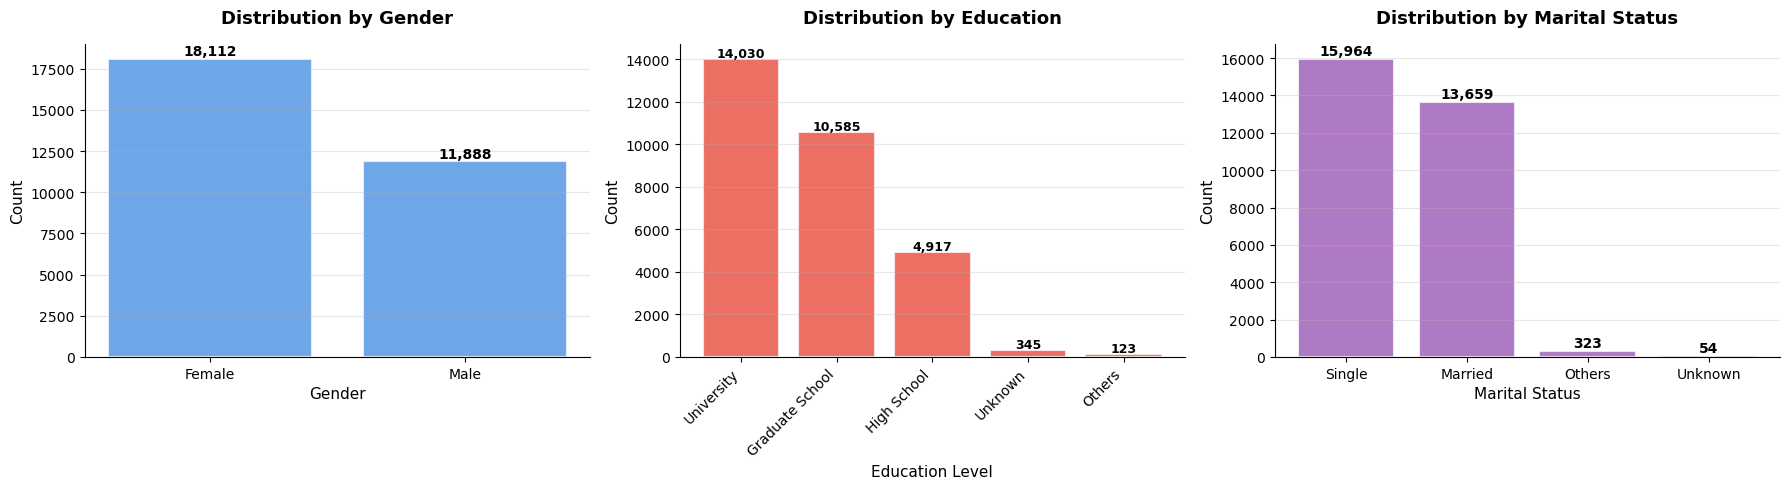

In [38]:
# Create a copy for display
df_display = df.copy()

# Map with fillna() to handle missing values
# SEX
df_display['SEX'] = df['SEX'].fillna(0).astype(int).map({
    1: 'Male',
    2: 'Female',
    0: 'Unknown'
}).fillna('Unknown')  # Handle any unmapped values

# EDUCATION
df_display['EDUCATION'] = df['EDUCATION'].fillna(0).astype(int).map({
    1: 'Graduate School',
    2: 'University',
    3: 'High School',
    4: 'Others',
    5: 'Unknown',
    6: 'Unknown',
    0: 'Unknown'
}).fillna('Unknown')

# MARRIAGE
df_display['MARRIAGE'] = df['MARRIAGE'].fillna(0).astype(int).map({
    1: 'Married',
    2: 'Single',
    3: 'Others',
    0: 'Unknown'
}).fillna('Unknown')

# Now create bar plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# SEX
sex_counts = df_display['SEX'].value_counts()
axes[0].bar(range(len(sex_counts)), sex_counts.values, color='#4A90E2', alpha=0.8, edgecolor='white', linewidth=1.5)
axes[0].set_xticks(range(len(sex_counts)))
axes[0].set_xticklabels(sex_counts.index, rotation=0)
axes[0].set_title('Distribution by Gender', fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel('Gender', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
for i, val in enumerate(sex_counts.values):
    axes[0].text(i, val + 200, f'{val:,}', ha='center', fontsize=10, fontweight='bold')

# EDUCATION
edu_counts = df_display['EDUCATION'].value_counts()
axes[1].bar(range(len(edu_counts)), edu_counts.values, color='#E74C3C', alpha=0.8, edgecolor='white', linewidth=1.5)
axes[1].set_xticks(range(len(edu_counts)))
axes[1].set_xticklabels(edu_counts.index, rotation=45, ha='right')
axes[1].set_title('Distribution by Education', fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel('Education Level', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
for i, val in enumerate(edu_counts.values):
    axes[1].text(i, val + 100, f'{val:,}', ha='center', fontsize=9, fontweight='bold')

# MARRIAGE
marriage_counts = df_display['MARRIAGE'].value_counts()
axes[2].bar(range(len(marriage_counts)), marriage_counts.values, color='#9B59B6', alpha=0.8, edgecolor='white', linewidth=1.5)
axes[2].set_xticks(range(len(marriage_counts)))
axes[2].set_xticklabels(marriage_counts.index, rotation=0)
axes[2].set_title('Distribution by Marital Status', fontsize=13, fontweight='bold', pad=15)
axes[2].set_xlabel('Marital Status', fontsize=11)
axes[2].set_ylabel('Count', fontsize=11)
axes[2].grid(axis='y', alpha=0.3)
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)
for i, val in enumerate(marriage_counts.values):
    axes[2].text(i, val + 200, f'{val:,}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

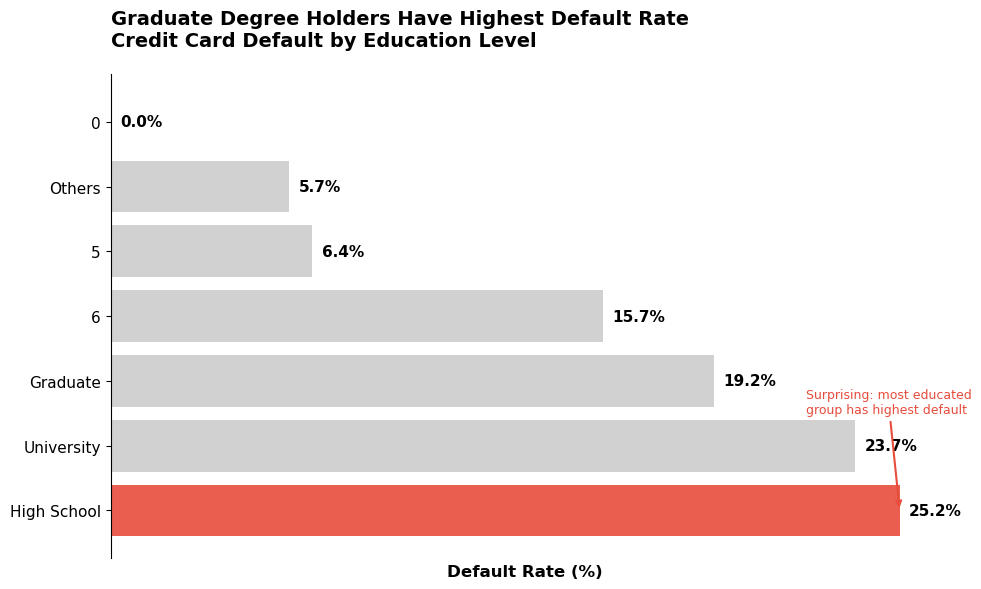

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# Example: Default rate by education level
df_display = df.copy()
df_display['EDUCATION'] = df['EDUCATION'].replace({
    1: 'Graduate',
    2: 'University', 
    3: 'High School',
    4: 'Others'
})

# Calculate default rate by education
default_by_edu = df_display.groupby('EDUCATION')['DEFAULT_PAYMENT_NEXT_MONTH'].mean() * 100
default_by_edu = default_by_edu.sort_values(ascending=False)

# Create SWD-style bar chart
fig, ax = plt.subplots(figsize=(10, 6))

# Bars with one color highlighted
colors = ['#E74C3C' if val == default_by_edu.max() else '#CCCCCC' 
          for val in default_by_edu.values]

bars = ax.barh(range(len(default_by_edu)), default_by_edu.values, color=colors, alpha=0.9)

# Direct labeling - put values on bars
for i, val in enumerate(default_by_edu.values):
    ax.text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=11, fontweight='bold')

# Clean styling - remove clutter (SWD principle)
ax.set_yticks(range(len(default_by_edu)))
ax.set_yticklabels(default_by_edu.index, fontsize=11)
ax.set_xlabel('Default Rate (%)', fontsize=12, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_xticks([])
ax.grid(False)

# Title that tells the story (SWD principle)
ax.set_title('Graduate Degree Holders Have Highest Default Rate\nCredit Card Default by Education Level',
             fontsize=14, fontweight='bold', loc='left', pad=20)

# Annotation for key insight (SWD principle)
ax.annotate('Surprising: most educated\ngroup has highest default', 
            xy=(default_by_edu.max(), 0), 
            xytext=(default_by_edu.max() - 3, 1.5),
            fontsize=9, color='#E74C3C',
            arrowprops=dict(arrowstyle='->', color='#E74C3C', lw=1.5))

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare data
education_mapping = {1: 'Graduate', 2: 'University', 3: 'High School', 4: 'Others'}
avg_credit = df.groupby('EDUCATION')['LIMIT_BAL'].mean()
avg_credit.index = avg_credit.index.map(education_mapping)
values = avg_credit.values / 1000
labels = avg_credit.index

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# LEFT: "Before" - Cluttered (what NOT to do)
ax1.bar(labels, values, color=['red', 'blue', 'green', 'purple'], 
        edgecolor='black', linewidth=2)
ax1.set_title('Before: Cluttered Chart', fontsize=12, fontweight='bold')
ax1.set_ylabel('Average Credit Limit ($K)', fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.set_facecolor('#F0F0F0')
for spine in ax1.spines.values():
    spine.set_linewidth(2)
ax1.tick_params(axis='x', rotation=45)

# RIGHT: "After" - SWD Style (clean and focused)
colors = ['#D3D3D3'] * len(values)
colors[0] = '#0077B6'  # Highlight Graduate
ax2.barh(labels, values, color=colors, edgecolor='none')

# Direct labels
for i, (label, value) in enumerate(zip(labels, values)):
    ax2.text(value + 3, i, f'${value:.0f}K', va='center', fontsize=11)

# Remove clutter
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.set_xticks([])
ax2.set_xlabel('')
ax2.tick_params(axis='y', length=0)

# Story-driven title
ax2.text(0, len(labels) + 0.3, 'After: Graduate degree holders\nreceive higher credit limits',
        fontsize=12, fontweight='bold')

plt.suptitle('Storytelling With Data: Before & After Comparison', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()